# ПРОГНОЗИРОВАНИЕ ПРОДАЖ И СРАВНЕНИЕ ГИПОТЕЗ
## Цель: Сравнение качества прогноза (RMSLE) для 4-х гипотез.

Исходные данные — продажи в магазине №1 Эквадора с 1.янв.2013 до 15.мрт.2016, цена на нефть и календарь праздников. Валидация проходит на данных с 1 по 15 марта 2016 с помощью метрики RMSLE.

Проверяем 4 гипотезы:
1. Наивный прогноз — продажи сегодня как 16 дней назад.
2. Машинное обучение учитывает закономерности рассчитанных признаков (lightgbm, catboost, xgboost).
3. Старые наблюдения снижают точность прогноза (прогноз без данных за 2013 год).
4. Поведение продаж товаров отличается. Поэтому нужно прогнозировать каждую группу отдельно. Стратегия: 
    - Для стабильных продаж используем регрессионный анализ.
    - Для нестабильных — сначала определяем, будет ли продажа сегодня, а затем применяем регрессию.
    - Для околонулевых продаж предполагаем, что их не будет.

In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_log_error
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMRegressor, LGBMClassifier
from catboost import CatBoostRegressor, CatBoostClassifier
from xgboost import XGBRegressor, XGBClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)

# ==============================================================================
# КОНФИГУРАЦИЯ
# ==============================================================================
DATA_PATH = '/kaggle/input/competitions/store-sales-time-series-forecasting/'

# Даты для эксперимента
TRAIN_END_DATE = '2016-02-29'
TEST_START_DATE = '2016-03-01'
TEST_END_DATE = '2016-03-15'

# Один магазин для прогнозирования
TARGET_STORE = 1

## Подготовка данных — загрузка и кодирование признаков
Расчет метрики прогноза и подготовка данных вынесены в отдельную часть.

In [2]:
# ==============================================================================
# ФУНКЦИИ
# ==============================================================================

def rmsle(y_true, y_pred):
    """Расчет метрики RMSLE"""
    y_true = np.maximum(y_true, 0)
    y_pred = np.maximum(y_pred, 0)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

def prepare_data_single_store(target_store=1):
    """Подготовка данных для одного магазина"""
    print(f"Загрузка и подготовка данных для store_nbr = {target_store}...")
    
    # 1. Загрузка данных
    df = pd.read_csv(DATA_PATH + 'train.csv')
    holidays = pd.read_csv(DATA_PATH + 'holidays_events.csv')
    oil = pd.read_csv(DATA_PATH + 'oil.csv')
    stores = pd.read_csv(DATA_PATH + 'stores.csv')

    # 2. Фильтрация по магазину
    df = df[df['store_nbr'] == target_store].copy()

    # 3. Преобразование дат
    df['date'] = pd.to_datetime(df['date'])
    oil['date'] = pd.to_datetime(oil['date'])
    holidays['date'] = pd.to_datetime(holidays['date'])

    # 4. Агрегация по family и date
    df = df.groupby(['family', 'date']).agg({
        'sales': 'sum', 
        'onpromotion': 'sum'
    }).reset_index()
    df['store_nbr'] = target_store

    # 5. Полный индекс (все даты × все family)
    all_families = df['family'].unique()
    min_date = df['date'].min()
    max_date = pd.to_datetime('2017-08-15') 
    all_dates = pd.date_range(min_date, max_date, freq='D')
    
    full_index = pd.MultiIndex.from_product(
        [all_dates, all_families],
        names=['date', 'family']
    )
    data = pd.DataFrame(index=full_index).reset_index()
    data['store_nbr'] = target_store

    # 6. Merge с данными о продажах
    data = data.merge(df, on=['date', 'family', 'store_nbr'], how='left')
    data['sales'] = data['sales'].fillna(0).astype('float32')
    data['onpromotion'] = data['onpromotion'].fillna(0).astype('float32')
    
    # 7. Информация о магазине
    store_info = stores[stores['store_nbr'] == target_store]
    data = data.merge(store_info[['store_nbr', 'city', 'state', 'type', 'cluster']], 
                      on='store_nbr', how='left')
    
    # 8. Нефть
    full_date_range = pd.date_range(data['date'].min(), data['date'].max(), freq='D')
    oil_complete = pd.DataFrame({'date': full_date_range}).merge(oil, on='date', how='left')
    oil_complete['dcoilwtico'] = oil_complete['dcoilwtico'].ffill().bfill()
    data = data.merge(oil_complete[['date', 'dcoilwtico']], on='date', how='left')
    data['dcoilwtico'] = data['dcoilwtico'].ffill().bfill().astype('float32')

    # 9. Праздники
    holidays_processed = holidays.rename(columns={'type': 'holiday_type'})
    data = data.merge(holidays_processed[['date', 'holiday_type', 'locale']], on='date', how='left')
    data['holiday_type'] = data['holiday_type'].fillna('None')
    data['is_holiday'] = (data['holiday_type'] != 'None').astype('int8')

    # 10. Временные признаки
    data['dow'] = data['date'].dt.dayofweek.astype('int8')
    data['month'] = data['date'].dt.month.astype('int8')
    data['day'] = data['date'].dt.day.astype('int8')
    data['is_weekend'] = (data['dow'] >= 5).astype('int8')
    data['is_payday'] = ((data['day'] == 15) | (data['date'].dt.is_month_end)).astype('int8')

    # 11. Лаги и статистики (по family)
    data['sales'] = data['sales'].fillna(0)
    grp = data.groupby(['family'])
    
    for lag in [16, 30, 60, 365]:
        data[f'lag_{lag}'] = grp['sales'].shift(lag).fillna(0).astype('float32')
        
    for win in [7, 14, 30]:
        data[f'rmean_{win}'] = grp['sales'].shift(16).rolling(win, min_periods=1).mean().fillna(0).astype('float32')
        data[f'rstd_{win}'] = grp['sales'].shift(16).rolling(win, min_periods=1).std().fillna(0).astype('float32')

    data['trend'] = (grp['sales'].shift(16) - grp['sales'].shift(30)).fillna(0).astype('float32')
    data['promo_last'] = grp['onpromotion'].shift(16).fillna(0).astype('float32')
    data['promo_mean'] = grp['onpromotion'].shift(16).rolling(30, min_periods=1).mean().fillna(0).astype('float32')

    # 12. Агрегаты
    data['is_train'] = (data['date'] <= pd.Timestamp(TRAIN_END_DATE)).astype('int8')
    
    family_avg = data[data['is_train'] == 1].groupby('family')['sales'].mean().reset_index()
    family_avg.columns = ['family', 'family_avg']
    data = data.merge(family_avg, on='family', how='left')
    
    store_avg = data[data['is_train'] == 1]['sales'].mean()
    data['store_avg'] = store_avg

    data['sales_log'] = np.log1p(data['sales']).astype('float32')

    # 13. Кодирование категориальных признаков
    categorical_cols = ['family', 'city', 'state', 'type', 'cluster', 'holiday_type']
    label_encoders = {}
    for col in categorical_cols:
        if col in data.columns:
            le = LabelEncoder()
            data[col] = data[col].astype(str)
            data[col] = le.fit_transform(data[col]).astype('int32')
            label_encoders[col] = le

    return data, label_encoders

In [3]:
# ==============================================================================
# ОСНОВНОЙ БЛОК
# ==============================================================================

# 1. Подготовка данных для одного магазина
data, label_encoders = prepare_data_single_store(target_store=TARGET_STORE)

# Фильтрация под эксперимент
df_exp = data[data['date'] <= TEST_END_DATE].copy()
df_exp = df_exp.sort_values(['family', 'date']).reset_index(drop=True)

mask_train = df_exp['date'] <= TRAIN_END_DATE
mask_test = (df_exp['date'] >= TEST_START_DATE) & (df_exp['date'] <= TEST_END_DATE)

train_df = df_exp[mask_train].copy()
test_df = df_exp[mask_test].copy()

feature_cols = [
    'store_nbr', 'family', 'onpromotion', 'city', 'state', 'type', 'cluster',
    'dcoilwtico', 'holiday_type', 'dow', 'month', 'day', 'is_weekend', 'is_payday',
    'lag_16', 'lag_30', 'lag_60', 'lag_365', 'rmean_7', 'rmean_14', 'rmean_30',
    'rstd_7', 'rstd_14', 'rstd_30', 'trend', 'promo_last', 'promo_mean',
    'store_avg', 'family_avg'
]

X_train = train_df[feature_cols].fillna(-999)
y_train = train_df['sales_log']
X_test = test_df[feature_cols].fillna(-999)
y_test = test_df['sales_log']

# Конфигурация моделей
models_config = {
    'LightGBM': LGBMRegressor(n_estimators=500, learning_rate=0.1, max_depth=6, verbose=-1, n_jobs=-1, random_state=42),
    'CatBoost': CatBoostRegressor(iterations=500, depth=6, learning_rate=0.1, verbose=0, thread_count=-1, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=6, verbosity=0, n_jobs=-1, random_state=42)
}

results_summary = {}

print(f"Данные подготовлены для store_nbr = {TARGET_STORE}")
print(f"Количество family: {train_df['family'].nunique()}")
print(f"Тренировочных записей: {len(train_df)}")
print(f"Тестовых записей: {len(test_df)}")

Загрузка и подготовка данных для store_nbr = 1...
Данные подготовлены для store_nbr = 1
Количество family: 33
Тренировочных записей: 38610
Тестовых записей: 495


Данные подготовлены к проверке гипотез.

## Проверка гипотез.

In [4]:
# ==============================================================================
# ПРОВЕРКА ГИПОТЕЗ
# ==============================================================================

# ==============================================================================
# ГИПОТЕЗА 1: НАИВНЫЙ ПРОГНОЗ
# ==============================================================================
print(f"\n" + "=" * 50)
print("ГИПОТЕЗА 1: НАИВНЫЙ ПРОГНОЗ")
test_df['naive_pred_log'] = np.log1p(test_df['lag_16'])
score_naive = rmsle(np.expm1(y_test), np.expm1(test_df['naive_pred_log']))
results_summary['H1: Naive (Lag -16)'] = score_naive
print(f"H1 Naive RMSLE: {score_naive:.5f}")
print("=" * 50)

# ==============================================================================
# ГИПОТЕЗА 2: ML (ВСЕ ДАННЫЕ)
# ==============================================================================
print("\n\n" + "=" * 50)
print("ГИПОТЕЗА 2: ML (ВСЕ ДАННЫЕ) — результаты по моделям")
print("=" * 50)

best_score_h2 = float('inf')
best_model_name_h2 = None

for name, model in models_config.items():
    model.fit(X_train, y_train)
    preds = np.maximum(np.expm1(model.predict(X_test)), 0)
    score = rmsle(np.expm1(y_test), preds)
    print(f"{name}: RMSLE = {score:.5f}")
    
    if score < best_score_h2:
        best_score_h2 = score
        best_model_name_h2 = name

results_summary['H2: ML (Full Data)'] = best_score_h2
print("-" * 50)
print(f"ЛУЧШАЯ МОДЕЛЬ для H2: {best_model_name_h2} с RMSLE = {best_score_h2:.5f}")
print("=" * 50)

# ==============================================================================
# ГИПОТЕЗА 3: ML (БЕЗ 2013 ГОДА)
# ==============================================================================
mask_train_no_2013 = (df_exp['date'] > '2013-12-31') & (df_exp['date'] <= TRAIN_END_DATE)
train_df_no_2013 = df_exp[mask_train_no_2013].copy()
X_train_h3 = train_df_no_2013[feature_cols].fillna(-999)
y_train_h3 = train_df_no_2013['sales_log']

print("\n\n" + "=" * 50)
print("ГИПОТЕЗА 3: ML (БЕЗ 2013 ГОДА) — результаты по моделям")
print("=" * 50)

best_score_h3 = float('inf')
best_model_name_h3 = None

for name, model in models_config.items():
    # Пересоздаем модель, чтобы не обучать на старых данных
    if name == 'LightGBM':
        m = LGBMRegressor(n_estimators=500, learning_rate=0.1, max_depth=6, verbose=-1, n_jobs=-1, random_state=42)
    elif name == 'CatBoost':
        m = CatBoostRegressor(iterations=500, depth=6, learning_rate=0.1, verbose=0, thread_count=-1, random_state=42)
    else:
        m = XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=6, verbosity=0, n_jobs=-1, random_state=42)
        
    m.fit(X_train_h3, y_train_h3)
    preds = np.maximum(np.expm1(m.predict(X_test)), 0)
    score = rmsle(np.expm1(y_test), preds)
    print(f"{name}: RMSLE = {score:.5f}")
    
    if score < best_score_h3:
        best_score_h3 = score
        best_model_name_h3 = name

results_summary['H3: ML (No 2013)'] = best_score_h3
print("-" * 50)
print(f"ЛУЧШАЯ МОДЕЛЬ для H3: {best_model_name_h3} с RMSLE = {best_score_h3:.5f}")
print("=" * 50)

# ==============================================================================
# ГИПОТЕЗА 4: АДАПТИВНЫЕ МОДЕЛИ (по группам family) — ТРИ ТИПА МОДЕЛЕЙ
# ==============================================================================
# Расчет доли нулей для каждой family
train_stats = train_df.groupby(['store_nbr', 'family']).agg({
    'sales': ['count', lambda x: (x == 0).sum()]
}).reset_index()
train_stats.columns = ['store_nbr', 'family', 'total_days', 'zero_days']
train_stats['zero_ratio'] = train_stats['zero_days'] / train_stats['total_days']

train_stats['series_type'] = pd.cut(
    train_stats['zero_ratio'],
    bins=[0, 0.3, 0.9, 1.0],
    labels=['stable', 'periodic', 'zero_heavy'],
    include_lowest=True
)

train_local = train_df.merge(train_stats[['store_nbr', 'family', 'series_type']], on=['store_nbr', 'family'], how='left')
test_local = test_df.merge(train_stats[['store_nbr', 'family', 'series_type']], on=['store_nbr', 'family'], how='left')

print(f"\n\n" + "=" * 50)
print("ГИПОТЕЗА 4: АДАПТИВНЫЕ МОДЕЛИ (по группам family)")
print("=" * 50)
print(f"\nРаспределение family по группам:")
print(train_stats['series_type'].value_counts())

# Конфигурация моделей для H4
h4_models_config = {
    'LightGBM': {
        'regressor': lambda: LGBMRegressor(n_estimators=500, learning_rate=0.1, max_depth=6, verbose=-1, n_jobs=-1, random_state=42),
        'classifier': lambda: LGBMClassifier(n_estimators=200, learning_rate=0.1, max_depth=4, verbose=-1, n_jobs=-1, random_state=42)
    },
    'CatBoost': {
        'regressor': lambda: CatBoostRegressor(iterations=500, depth=6, learning_rate=0.1, verbose=0, thread_count=-1, random_state=42),
        'classifier': lambda: CatBoostClassifier(iterations=200, depth=4, learning_rate=0.1, verbose=0, thread_count=-1, random_state=42)
    },
    'XGBoost': {
        'regressor': lambda: XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=6, verbosity=0, n_jobs=-1, random_state=42),
        'classifier': lambda: XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=4, verbosity=0, n_jobs=-1, random_state=42)
    }
}

h4_results = {}

for model_name, model_funcs in h4_models_config.items():
    print(f"\n" + "-" * 50)
    print(f"Обучение адаптивной модели: {model_name}")
    print("-" * 50)
    
    full_predictions = np.zeros(len(test_local))
    
    for series_type in ['stable', 'periodic', 'zero_heavy']:
        train_mask = train_local['series_type'] == series_type
        test_mask = test_local['series_type'] == series_type
        
        if train_mask.sum() == 0 or test_mask.sum() == 0:
            print(f"{series_type}: нет данных для обучения или прогноза")
            continue
            
        tr_grp = train_local[train_mask]
        te_grp = test_local[test_mask]
        
        X_tr = tr_grp[feature_cols].fillna(-999)
        y_tr = tr_grp['sales_log']
        X_te = te_grp[feature_cols].fillna(-999)
        y_te = te_grp['sales_log']
        
        if series_type == 'stable':
            # Стабильные продажи — только регрессия
            model = model_funcs['regressor']()
            model.fit(X_tr, y_tr)
            preds = np.maximum(np.expm1(model.predict(X_te)), 0)
            print(f"  {series_type}: регрессия, {len(tr_grp['family'].unique())} family")
            
        elif series_type == 'periodic':
            # Периодические — классификация + регрессия
            y_bin = (tr_grp['sales'] > 0).astype('int8')
            clf = model_funcs['classifier']()
            clf.fit(X_tr, y_bin)
            prob = clf.predict_proba(X_te)[:, 1]
            
            tr_pos = tr_grp[tr_grp['sales'] > 0]
            if len(tr_pos) > 0:
                reg = model_funcs['regressor']()
                reg.fit(tr_pos[feature_cols].fillna(-999), tr_pos['sales_log'])
                vol = np.maximum(np.expm1(reg.predict(X_te)), 0)
                preds = prob * vol
            else:
                preds = np.zeros(len(te_grp))
            print(f"  {series_type}: классификация + регрессия, {len(tr_grp['family'].unique())} family")
             
        elif series_type == 'zero_heavy':
            # Околонулевые — продажи равны нулю
            preds = np.zeros(len(te_grp))
            print(f"  {series_type}: нулевые продажи, {len(tr_grp['family'].unique())} family")
        
        # Запись прогнозов по индексам
        for i, idx in enumerate(te_grp.index):
            full_predictions[test_local.index.get_loc(idx)] = preds[i]
    
    score_h4 = rmsle(np.expm1(test_local['sales_log']), full_predictions)
    h4_results[f'H4: Adaptive ({model_name})'] = score_h4
    results_summary[f'H4: Adaptive ({model_name})'] = score_h4
    print(f"  >>> {model_name} RMSLE: {score_h4:.5f}")

print("\n" + "=" * 50)
print("ИТОГИ ГИПОТЕЗЫ 4: АДАПТИВНЫЕ МОДЕЛИ")
print("=" * 50)
for model_name, score in h4_results.items():
    print(f"{model_name}: {score:.5f}")

best_h4_model = min(h4_results, key=h4_results.get)
print("-" * 50)
print(f"ЛУЧШАЯ МОДЕЛЬ для H4: {best_h4_model} с RMSLE = {h4_results[best_h4_model]:.5f}")
print("=" * 50)


ГИПОТЕЗА 1: НАИВНЫЙ ПРОГНОЗ
H1 Naive RMSLE: 0.78373


ГИПОТЕЗА 2: ML (ВСЕ ДАННЫЕ) — результаты по моделям
LightGBM: RMSLE = 0.40170
CatBoost: RMSLE = 0.45369
XGBoost: RMSLE = 0.39535
--------------------------------------------------
ЛУЧШАЯ МОДЕЛЬ для H2: XGBoost с RMSLE = 0.39535


ГИПОТЕЗА 3: ML (БЕЗ 2013 ГОДА) — результаты по моделям
LightGBM: RMSLE = 0.44938
CatBoost: RMSLE = 0.42646
XGBoost: RMSLE = 0.55017
--------------------------------------------------
ЛУЧШАЯ МОДЕЛЬ для H3: CatBoost с RMSLE = 0.42646


ГИПОТЕЗА 4: АДАПТИВНЫЕ МОДЕЛИ (по группам family)

Распределение family по группам:
series_type
stable        20
periodic      10
zero_heavy     3
Name: count, dtype: int64

--------------------------------------------------
Обучение адаптивной модели: LightGBM
--------------------------------------------------
  stable: регрессия, 20 family
  periodic: классификация + регрессия, 10 family
  zero_heavy: нулевые продажи, 3 family
  >>> LightGBM RMSLE: 0.42142

-----------------

Прогнозы готовы, визуально сравним результаты.

## Визуализация качества прогноза.

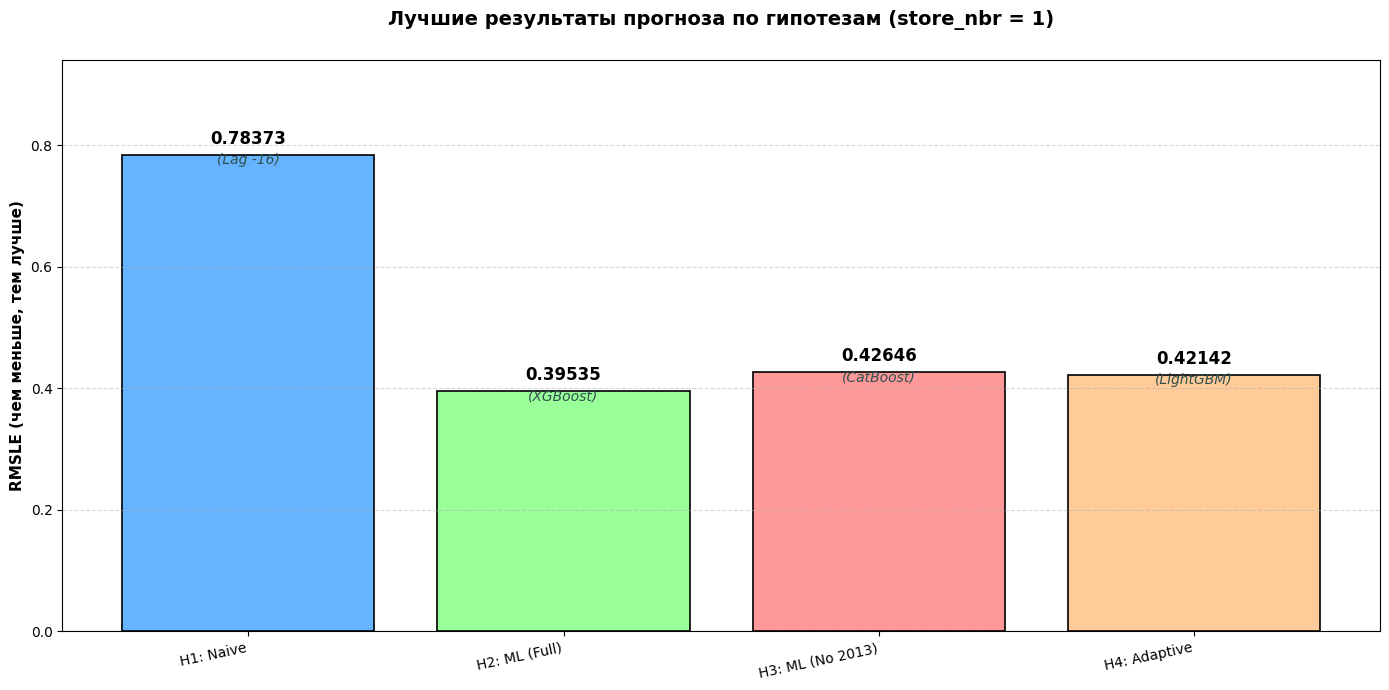


СВОДНАЯ ТАБЛИЦА: ЛУЧШИЕ РЕЗУЛЬТАТЫ ПО ГИПОТЕЗАМ
Гипотеза                      RMSLE             Модель
---------------------------------------------------------------------------
H1: Naive                   0.78373            Lag -16
H2: ML (Full)               0.39535            XGBoost
H3: ML (No 2013)            0.42646           CatBoost
H4: Adaptive                0.42142           LightGBM

АБСОЛЮТНЫЙ ЛИДЕР: H2: ML (Full) (XGBoost)
   RMSLE: 0.39535
   Улучшение относительно H1 (Naive): 49.56%


In [5]:
# ==============================================================================
# ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ==============================================================================

# Подготовка данных для графика: (название для оси, значение RMSLE, подпись модели)
plot_data = [
    {'label': 'H1: Naive', 'score': 0.78373, 'model': 'Lag -16'},
    {'label': 'H2: ML (Full)', 'score': 0.39535, 'model': 'XGBoost'},
    {'label': 'H3: ML (No 2013)', 'score': 0.42646, 'model': 'CatBoost'},
    {'label': 'H4: Adaptive', 'score': 0.42142, 'model': 'LightGBM'}
]

# Построение графика
plt.figure(figsize=(14, 7))
colors = ['#66b3ff', '#99ff99', '#ff9999', '#ffcc99']
bars = plt.bar([item['label'] for item in plot_data], 
               [item['score'] for item in plot_data], 
               color=colors, edgecolor='black', linewidth=1.2)

# Добавление значений и названий моделей на столбцы
for i, (bar, item) in enumerate(zip(bars, plot_data)):
    height = bar.get_height()
    # Значение RMSLE (жирным, крупным)
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.012, 
             f'{item["score"]:.5f}', 
             ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')
    # Название модели (курсивом, серым, чуть меньше)
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.003, 
             f'({item["model"]})', 
             ha='center', va='top', fontsize=10, style='italic', color='darkslategray')

# Оформление графика
plt.ylabel('RMSLE (чем меньше, тем лучше)', fontsize=11, fontweight='bold')
plt.title(f'Лучшие результаты прогноза по гипотезам (store_nbr = {TARGET_STORE})', 
          fontsize=14, fontweight='bold', pad=25)
plt.xticks(rotation=12, ha='right', fontsize=10)
plt.ylim(0, max(item['score'] for item in plot_data) * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.5, linewidth=0.8)
plt.tight_layout()
plt.show()

# Вывод сводной таблицы
print("\n" + "=" * 75)
print("СВОДНАЯ ТАБЛИЦА: ЛУЧШИЕ РЕЗУЛЬТАТЫ ПО ГИПОТЕЗАМ")
print("=" * 75)
print(f"{'Гипотеза':<22} {'RMSLE':>12} {'Модель':>18}")
print("-" * 75)
for item in plot_data:
    print(f"{item['label']:<22} {item['score']:>12.5f} {item['model']:>18}")
print("=" * 75)

# Определение абсолютного лидера
best_overall = min(plot_data, key=lambda x: x['score'])
print(f"\nАБСОЛЮТНЫЙ ЛИДЕР: {best_overall['label']} ({best_overall['model']})")
print(f"   RMSLE: {best_overall['score']:.5f}")

# Сравнение с базовой моделью
baseline = plot_data[0]['score']
improvement = (baseline - best_overall['score']) / baseline * 100
print(f"   Улучшение относительно H1 (Naive): {improvement:.2f}%")

print("=" * 75)

**Ключевые выводы**

1. XGBoost (H2) — лучший метод с наименьшей ошибкой (RMSLE=0,39535), снижает ошибку на 49,56% относительно наивного прогноза (H1).
2. Данные за 2013 год (H3) важны: их удаление ухудшает прогноз (RMSLE=0,42646), что подтверждает их полезность.
3. Адаптивный подход (H4) уступает XGBoost, но лучше H1 и H3 (RMSLE=0,42142). Эффективен для детализированной сегментации по группам family.
4. XGBoost стабилен, LightGBM хорош для адаптивного подхода, CatBoost лучше работает с неполными данными.
5. Сегментация по family снижает ошибку, но уступает единой мощной модели XGBoost.